In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
from scipy.stats import zscore

In [5]:
df = pd.read_csv('sierraleone-bumbuna.csv')

In [6]:
import os


In [10]:
if os.path.exists('data'):
    print("Contents of 'data/' folder:")
    print(os.listdir('data'))  # Lists all files in 'data/' folder
else:
    print("'data/' folder not found in the current directory.")

Contents of 'data/' folder:
['benin_clean.csv', 'sierra_leone_clean.csv', 'togo_clean.csv']


In [11]:
print(df.describe())

                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.900000       0.000000   
25%         0.000000      23.1000

In [12]:
print(df.isna().sum())

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


In [13]:
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

In [14]:
df[cols] = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [15]:
outliers = df[(df[cols].abs() > 3).any(axis=1)]

In [18]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [19]:
df.to_csv('data/sierra_leone_clean.csv', index=False)

In [20]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

<Axes: xlabel='Timestamp'>

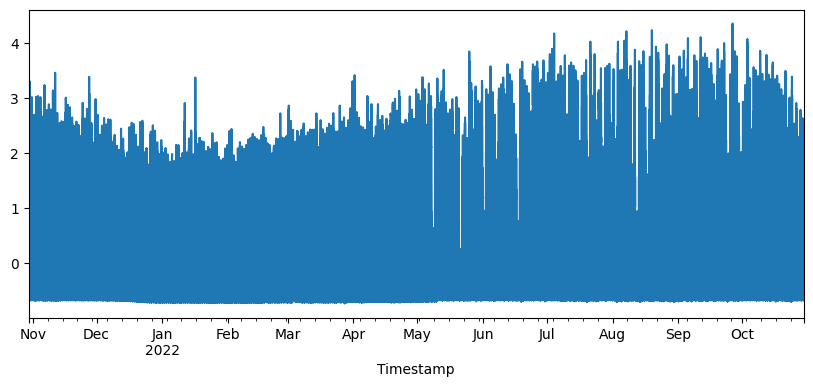

In [21]:
df.set_index('Timestamp')['GHI'].plot(figsize=(10, 4))

In [22]:
import seaborn as sns

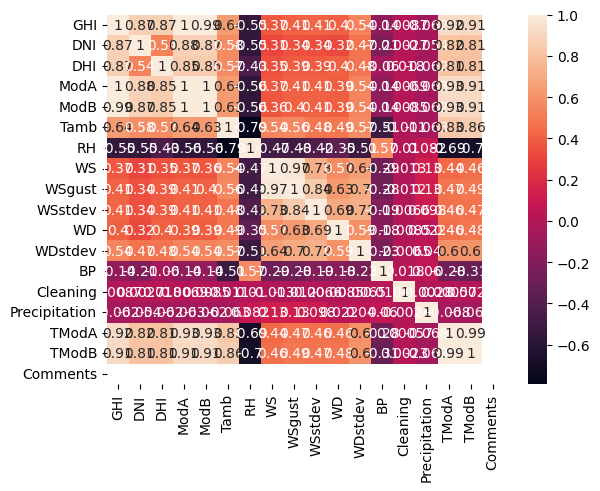

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True); plt.show()